# 07. 応用 — 物理・生物・金融・機械学習・制御

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture |
| Applied | 2. 物理 〜 6. 制御 |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

ODE は分野を越えた共通言語です。本章は、これまでの道具を各分野の代表問題に当てはめます。
同じ「変化率をルールとして与える」枠組みが、振動・感染・金利・深層学習・制御に現れます。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import systems, solvers, plotting, datasets

## 2. 物理 — 強制減衰振動と共振 (Applied)

外力つき振動子 $\ddot{x} + 2\gamma\dot{x} + \omega^2 x = F_0\cos(\Omega t)$ を時間積分し、
駆動振動数 $\Omega$ を固有 $\omega$ に合わせると振幅が育つ(共振)様子を見ます。

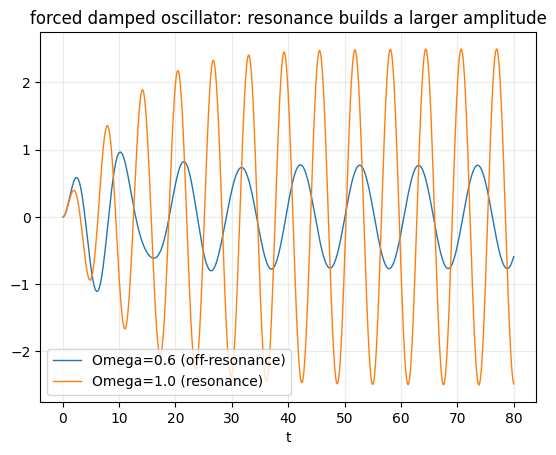

In [3]:
import numpy as np

# Forced damped oscillator: transient + steady oscillation; near-resonant drive.
w, g, F0 = 1.0, 0.1, 0.5
for Omega, label in [(0.6, "off-resonance"), (1.0, "resonance")]:
    f = systems.harmonic_oscillator(w, g, forcing=lambda t, Om=Omega: F0 * np.cos(Om * t))
    t = np.linspace(0, 80, 4000)
    Y = solvers.rk4(f, [0.0, 0.0], t)
    plt.plot(t, Y[:, 0], lw=1, label=f"Omega={Omega} ({label})")
plt.legend()
plt.grid(alpha=0.25)
plt.xlabel("t")
plt.title("forced damped oscillator: resonance builds a larger amplitude")
plt.show()

## 3. 生物 — 感染症の介入効果

SIR を使い、接触率 $\beta$ を下げる(隔離・ワクチン)とピークがどう変わるかを比べます
(いわゆる「流行曲線を平らにする」)。

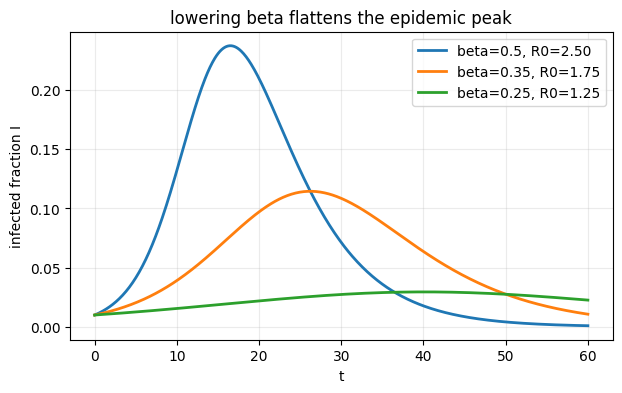

In [4]:
# Flattening the curve: lowering beta reduces and delays the infection peak.
sc = datasets.sir_scenario()
t = sc.t
fig, ax = plt.subplots(figsize=(7, 4))
for beta in (0.5, 0.35, 0.25):
    f = systems.sir(beta=beta, gamma=sc.params["gamma"], N=1.0)
    Y = solvers.rk4(f, sc.y0, t)
    ax.plot(t, Y[:, 1], lw=2, label=f"beta={beta}, R0={beta / sc.params['gamma']:.2f}")
ax.legend()
ax.grid(alpha=0.25)
ax.set_xlabel("t")
ax.set_ylabel("infected fraction I")
ax.set_title("lowering beta flattens the epidemic peak")
plt.show()

## 4. 金融 — 平均回帰 (Ornstein–Uhlenbeck / Vasicek の決定論部分)

短期金利モデル(Vasicek)は確率微分方程式

$$
dr_t = \kappa(\theta - r_t)\,dt + \sigma\,dW_t
$$

です。$\sigma\,dW_t$ はランダムな揺らぎ(ブラウン運動)。これを取り除いた **決定論部分**

$$
\frac{dr}{dt} = \kappa(\theta - r)
$$

は線形一階 ODE で、解は $r(t) = \theta + (r_0-\theta)e^{-\kappa t}$。
どの初期値からも長期平均 $\theta$ へ **平均回帰** します。ODE は SDE の「骨格(ドリフト)」を与えます。

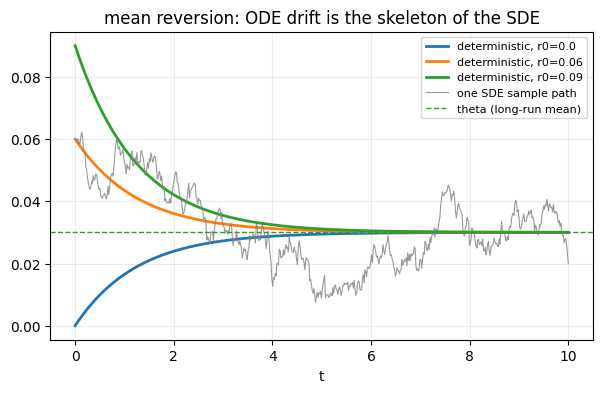

In [5]:
import numpy as np

# Deterministic skeleton of Vasicek: mean reversion to theta. Plus one noisy sample path.
kappa, theta, sigma = 0.8, 0.03, 0.015
t = np.linspace(0, 10, 600)
f = lambda tt, r: kappa * (theta - r)
fig, ax = plt.subplots(figsize=(7, 4))
for r0 in (0.0, 0.06, 0.09):
    r_det = solvers.rk4(f, [r0], t)[:, 0]
    ax.plot(t, r_det, lw=2, label=f"deterministic, r0={r0}")
# one Euler-Maruyama path on top (noise illustration only, seed fixed)
rng = np.random.default_rng(0)
dt = t[1] - t[0]
r = np.empty_like(t)
r[0] = 0.06
for k in range(t.size - 1):
    r[k + 1] = r[k] + kappa * (theta - r[k]) * dt + sigma * np.sqrt(dt) * rng.standard_normal()
ax.plot(t, r, color="gray", lw=0.8, alpha=0.8, label="one SDE sample path")
ax.axhline(theta, color="#2ca02c", ls="--", lw=1, label="theta (long-run mean)")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
ax.set_xlabel("t")
ax.set_title("mean reversion: ODE drift is the skeleton of the SDE")
plt.show()

## 5. 機械学習 — Neural ODE の概念的導入

残差ネット $z_{k+1} = z_k + \Delta t\, f_\theta(z_k)$ は、Euler 1 ステップそのもの。
層を無限に細かくした極限が **Neural ODE** $dz/dt = f_\theta(z)$ です。
ここでは学習は行わず、固定した $f_\theta(z)=Az$ の **流れ** が点群をどう変形するかだけを見ます
(「深さ = 時間」のイメージ)。

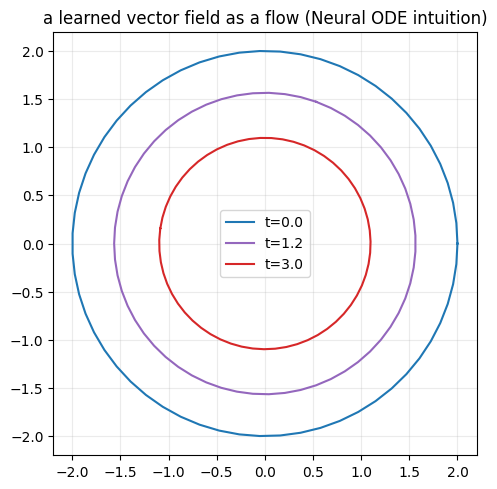

In [6]:
import numpy as np

# Neural-ODE intuition: a fixed vector field f(z)=Az transforms a point cloud as "depth" t grows.
A = np.array([[-0.2, -1.0], [1.0, -0.2]])  # spiral-in flow
f = systems.linear_system(A)
theta = np.linspace(0, 2 * np.pi, 60)
cloud = np.c_[np.cos(theta), np.sin(theta)] * 2.0  # initial ring
t = np.linspace(0, 3, 50)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for snap, col in [(0, "#1f77b4"), (20, "#9467bd"), (49, "#d62728")]:
    pts = np.array([solvers.rk4(f, p, t)[snap] for p in cloud])
    ax.plot(np.r_[pts[:, 0], pts[0, 0]], np.r_[pts[:, 1], pts[0, 1]], color=col,
            label=f"t={t[snap]:.1f}")
ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.25)
ax.set_title("a learned vector field as a flow (Neural ODE intuition)")
plt.show()

## 6. 制御 — フィードバックで安定化

不安定な系 $\dot{x} = a x$($a>0$ は発散)に、状態フィードバック $u = -k x$ を加えると
$\dot{x} = (a-k)x$。ゲイン $k>a$ で **安定化** できます。制御の最も基本的なアイデアです。

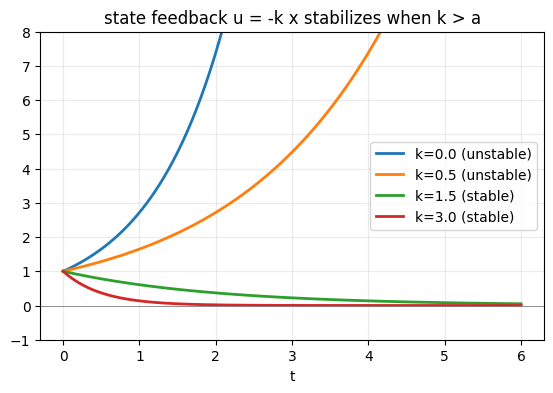

In [7]:
import numpy as np

# Feedback stabilization: unstable dx/dt = a x becomes stable with u = -k x (k > a).
a = 1.0
t = np.linspace(0, 6, 300)
fig, ax = plt.subplots(figsize=(6.5, 4))
for k in (0.0, 0.5, 1.5, 3.0):
    f = lambda tt, x, kk=k: (a - kk) * x
    Y = solvers.rk4(f, [1.0], t)[:, 0]
    ax.plot(t, Y, lw=2, label=f"k={k} ({'stable' if k > a else 'unstable'})")
ax.axhline(0, color="gray", lw=0.6)
ax.set_ylim(-1, 8)
ax.legend()
ax.grid(alpha=0.25)
ax.set_xlabel("t")
ax.set_title("state feedback u = -k x stabilizes when k > a")
plt.show()

## Exercises

1. 強制振動子で $\Omega$ を 0.2〜2.0 と変え、定常振幅のピークが $\omega$ 付近に来ることを数値で確かめよ。
2. Vasicek の決定論解 $r(t)=\theta+(r_0-\theta)e^{-\kappa t}$ を導き、$\kappa$ が大きいほど速く回帰することを示せ。
3. 制御の例で、$a=2$ のとき安定化に必要な最小ゲイン $k$ を求めよ。

## Advanced Notes

- **SDE と Fokker–Planck**: $dr=\kappa(\theta-r)dt+\sigma dW$ の確率分布は Fokker–Planck 方程式(PDE!)に従う。ODE/PDE/確率が交わる地点。
- **Neural ODE の学習**: 随伴感度法 (adjoint) で勾配をメモリ効率よく計算する。`torchdiffeq` などが有名。
- **最適制御と Pontryagin**: コスト最小化のための最適入力は、状態と随伴変数の連立 ODE(ハミルトン系)で特徴づけられる。
- **線形制御理論**: $\dot{\mathbf{x}}=A\mathbf{x}+B\mathbf{u}$ の安定化は、$A-BK$ の固有値を左半平面に置く極配置問題になる。